<a href="https://colab.research.google.com/github/pravallika322/sentimental-analysis-based-on-twitter-data/blob/main/Ensembling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers==4.55.4 datasets accelerate evaluate sentencepiece

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving clean_d_tweets.csv to clean_d_tweets (1).csv
Saving clean_non_d_tweets.csv to clean_non_d_tweets (1).csv


In [ ]:
depression = pd.read_csv("clean_d_tweets.csv")
non_depression = pd.read_csv("clean_non_d_tweets.csv")

In [ ]:
print(depression.shape)
print(non_depression.shape)

print(depression.columns)

(3082, 38)
(4687, 38)
Index(['id', 'conversation_id', 'created_at', 'date', 'timezone', 'place',
       'tweet', 'language', 'hashtags', 'cashtags', 'user_id', 'user_id_str',
       'username', 'name', 'day', 'hour', 'link', 'urls', 'photos', 'video',
       'thumbnail', 'retweet', 'nlikes', 'nreplies', 'nretweets', 'quote_url',
       'search', 'near', 'geo', 'source', 'user_rt_id', 'user_rt',
       'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src',
       'trans_dest'],
      dtype='object')


In [ ]:
depression["label"] = 1
non_depression["label"] = 0

In [ ]:
print(depression.columns.tolist())

['id', 'conversation_id', 'created_at', 'date', 'timezone', 'place', 'tweet', 'language', 'hashtags', 'cashtags', 'user_id', 'user_id_str', 'username', 'name', 'day', 'hour', 'link', 'urls', 'photos', 'video', 'thumbnail', 'retweet', 'nlikes', 'nreplies', 'nretweets', 'quote_url', 'search', 'near', 'geo', 'source', 'user_rt_id', 'user_rt', 'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src', 'trans_dest', 'label']


In [ ]:
df = pd.concat([
    depression[['tweet', 'label']],
    non_depression[['tweet', 'label']]
], ignore_index=True)

df = df.dropna()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(7745, 2)


,tweet,label
0,sometimes i just want to down a bottle of pill...,1
1,you do not have to indirectly tell me that i b...,1
2,i plan to bring it tomorrow,0
3,will win every prize that day,0
4,i be literally so tire of be nice to people an...,1


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['label'],
    random_state=42
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(5576, 2)
(620, 2)
(1549, 2)


In [ ]:
from transformers import BertTokenizer

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
MAX_LEN = 128

def tokenize_data(texts):
    return bert_tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    )

In [ ]:
train_encodings = tokenize_data(train_df["tweet"])
val_encodings = tokenize_data(val_df["tweet"])
test_encodings = tokenize_data(test_df["tweet"])

In [ ]:
import torch

class TweetDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = TweetDataset(train_encodings, train_df["label"])
val_dataset = TweetDataset(val_encodings, val_df["label"])
test_dataset = TweetDataset(test_encodings, test_df["label"])

In [ ]:
from transformers import BertForSequenceClassification

bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./bert_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True
)

In [ ]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

In [ ]:
from transformers import Trainer

trainer = Trainer(

    model=bert_model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,0.284500,0.226131,0.914516
2,0.169000,0.283044,0.916129
3,0.060900,0.315876,0.925806


TrainOutput(global_step=1047, training_loss=0.18722187413868727, metrics={'train_runtime': 447.2397, 'train_samples_per_second': 37.403, 'train_steps_per_second': 2.341, 'total_flos': 713495515482720.0, 'train_loss': 0.18722187413868727, 'epoch': 3.0})

In [37]:
from transformers import RobertaTokenizer

roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [38]:
MAX_LEN = 128

def roberta_tokenize(texts):

    return roberta_tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LEN
    )

In [39]:
train_encodings_r = roberta_tokenize(train_df["tweet"])

val_encodings_r = roberta_tokenize(val_df["tweet"])

test_encodings_r = roberta_tokenize(test_df["tweet"])

In [40]:
train_dataset_r = TweetDataset(
    train_encodings_r,
    train_df["label"]
)

val_dataset_r = TweetDataset(
    val_encodings_r,
    val_df["label"]
)

test_dataset_r = TweetDataset(
    test_encodings_r,
    test_df["label"]
)

In [41]:
from transformers import RobertaForSequenceClassification

roberta_model = RobertaForSequenceClassification.from_pretrained(

    "roberta-base",

    num_labels=2
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
training_args_r = TrainingArguments(

    output_dir="./roberta_results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    report_to="none",

    load_best_model_at_end=True
)

In [43]:
trainer_r = Trainer(

    model=roberta_model,

    args=training_args_r,

    train_dataset=train_dataset_r,

    eval_dataset=val_dataset_r,

    compute_metrics=compute_metrics
)

In [44]:
trainer_r.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.332425,0.885484
2,0.328900,0.352985,0.903226
3,0.193700,0.313866,0.925806


TrainOutput(global_step=1047, training_loss=0.2574132210659548, metrics={'train_runtime': 590.9141, 'train_samples_per_second': 28.309, 'train_steps_per_second': 1.772, 'total_flos': 816651493624800.0, 'train_loss': 0.2574132210659548, 'epoch': 3.0})

In [45]:
bert_output = trainer.predict(test_dataset)

bert_probs = torch.softmax(
    torch.tensor(bert_output.predictions),
    dim=1
).numpy()

In [46]:
roberta_output = trainer_r.predict(test_dataset_r)

roberta_probs = torch.softmax(
    torch.tensor(roberta_output.predictions),
    dim=1
).numpy()

In [47]:
ensemble_probs = (bert_probs + roberta_probs) / 2

ensemble_predictions = np.argmax(
    ensemble_probs,
    axis=1
)

In [48]:
true_labels = test_df["label"].values

In [49]:
from sklearn.metrics import accuracy_score

ensemble_accuracy = accuracy_score(
    true_labels,
    ensemble_predictions
)

print("Ensemble Accuracy:", ensemble_accuracy)

Ensemble Accuracy: 0.9302775984506133


In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        ensemble_predictions
    )
)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       934
           1       0.91      0.91      0.91       615

    accuracy                           0.93      1549
   macro avg       0.93      0.93      0.93      1549
weighted avg       0.93      0.93      0.93      1549



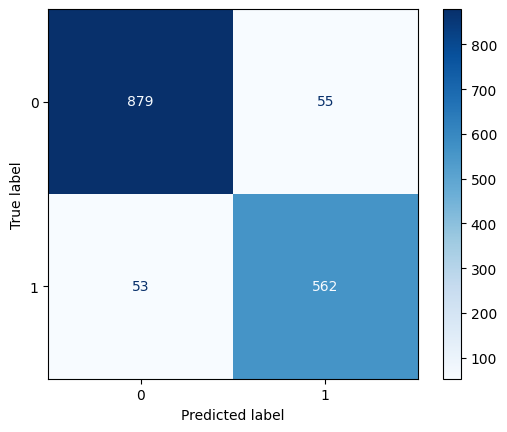

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    ensemble_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.show()

In [52]:
trainer.save_model("bert_model")

trainer_r.save_model("roberta_model")

In [57]:
import torch

# Move models to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert_model.to(device)
roberta_model.to(device)

bert_model.eval()
roberta_model.eval()

def predict_sentiment(text):

    bert_inputs = bert_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    roberta_inputs = roberta_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to GPU
    bert_inputs = {k: v.to(device) for k, v in bert_inputs.items()}
    roberta_inputs = {k: v.to(device) for k, v in roberta_inputs.items()}

    with torch.no_grad():

        bert_logits = bert_model(**bert_inputs).logits
        roberta_logits = roberta_model(**roberta_inputs).logits

        bert_prob = torch.softmax(bert_logits, dim=1)
        roberta_prob = torch.softmax(roberta_logits, dim=1)

        final_prob = (bert_prob + roberta_prob) / 2

        prediction = torch.argmax(final_prob, dim=1).item()

    if prediction == 1:
        return "Depression Tweet"
    else:
        return "Non-Depression Tweet"

In [58]:
print(predict_sentiment("I feel lonely and hopeless"))

Depression Tweet
